In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm
import numpy as np
import healpy as hp
import jax

sys.path.append("../..")
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band
from models.validation_models import RandomModel, PoissonModel

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[gpu(id=0)]


## 1. HMC performs fine

In [2]:
run_dir = "../../outputs/poiss_sim/hmc_230823_noNT"
model = PoissonModel()

In [3]:
truth_arr = np.load(f"{run_dir}/truth_arr.npy")
n_run = 30

p_runs = []
for i_run in range(n_run):
    samples = pickle.load(open(f"{run_dir}/samples_{i_run}.p", "rb"))
    p = []
    for i in range(model.n_temp):
        s = np.array(samples[f'temp_{i}'])
        m = truth_arr[i]
        p.append(find_hdi_prob(s, m, level=15))
    p_runs.append(p)
p_runs = np.array(p_runs).T
p_runs = np.sort(p_runs, axis=1)

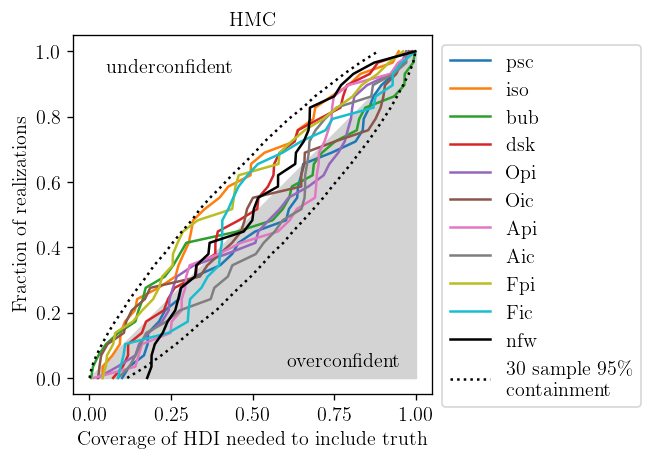

In [5]:
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for i, p in enumerate(p_runs):
    color = f'C{i}'
    if model.labels[i] == 'nfw':
        color = 'k'
    ax.plot(p, np.linspace(0, 1, n_run), color=color, label=model.labels[i])

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
       title=f'HMC')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
plt.savefig(f"{run_dir}/roc.pdf")

## 2. SVI

### 2.1 generate samples

In [79]:
test = False
save_dir = "../../outputs/poiss_sim/svi_230826"
n_run = 30

model = PoissonModel()
truth_arr = np.load(f"{save_dir}/truth_arr.npy")
model.set_truth(truth_arr)

for i_run in range(n_run if not test else 1):
    rng_key = jax.random.PRNGKey(42*i_run)
    rng_key, key = jax.random.split(rng_key)
    counts = model.generate_counts(rng_key)
    
    print(f"Running index={i_run}...")
    rng_key, key = jax.random.split(rng_key)
    model.fit_svi(key, guide='iaf', num_flows=5, hidden_dims=[512, 512],
                  n_steps=10000, lr=5e-5, num_particles=64, counts=counts)
    rng_key, key = jax.random.split(rng_key)
    samples = model.get_svi_samples(50000, key)
    if not test:
        pickle.dump(samples, open(f"{save_dir}/samples_{i_run}.p", "wb"))
    if test:
        plt.plot(model.svi_results.losses)
        plt.loglog()

Running index=0...


100%|██████████| 10000/10000 [00:14<00:00, 691.06it/s, init loss: 62962.8945, avg. loss [9501-10000]: 21047.9473]


Running index=1...


100%|██████████| 10000/10000 [00:14<00:00, 685.28it/s, init loss: 64173.9609, avg. loss [9501-10000]: 20985.5156]


Running index=2...


...

100%|██████████| 10000/10000 [00:14<00:00, 691.29it/s, init loss: 61614.4727, avg. loss [9501-10000]: 20873.7949]


Running index=28...


100%|██████████| 10000/10000 [00:14<00:00, 670.81it/s, init loss: 58786.7695, avg. loss [9501-10000]: 20959.1426]


Running index=29...


100%|██████████| 10000/10000 [00:14<00:00, 700.27it/s, init loss: 62682.9062, avg. loss [9501-10000]: 20983.7344]


In [80]:
roc_runs = []
for i_run in tqdm(range(n_run)):
    samples = pickle.load(open(f"{save_dir}/samples_{i_run}.p", "rb"))
    roc = []
    for i_temp in range(model.n_temp):
        s = np.array(samples[f'temp_{i_temp}'])
        m = truth_arr[i_temp]
        roc.append(find_hdi_prob(s, m, level=15))
    roc_runs.append(roc)
roc_runs = np.array(roc_runs).T
roc_runs = np.sort(roc_runs, axis=1)

100%|██████████| 30/30 [00:02<00:00, 12.83it/s]


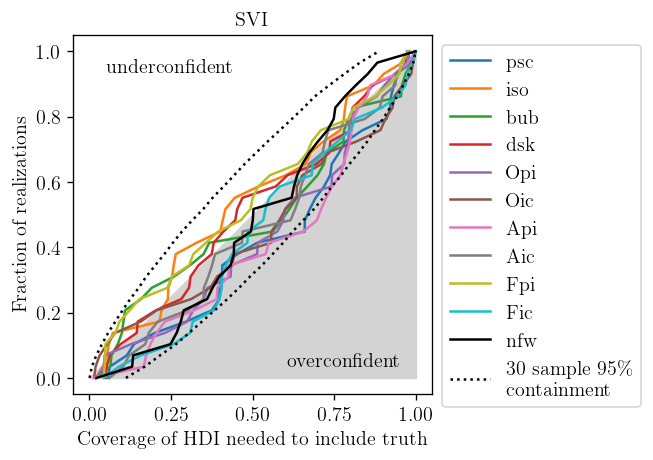

In [81]:
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for i, p in enumerate(roc_runs):
    color = f'C{i}'
    if model.labels[i] == 'nfw':
        color = 'k'
    ax.plot(p, np.linspace(0, 1, n_run), color=color, label=model.labels[i])

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
       title=f'SVI')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
plt.savefig(f"{save_dir}/roc.pdf")

### 2.2 Look at the templates and roc score

In [54]:
roc_standard = np.linspace(0, 1, n_run)
roc_scores = np.sum(- (roc_runs - roc_standard[None, :]) / n_run, axis=1)
print(- np.sum(invcdf_upper - roc_standard) / n_run)
print(roc_scores)

-0.07667678673156972
[-0.07570465 -0.04620392 -0.04547577 -0.04156799 -0.08955383 -0.13160217
 -0.21172821 -0.09422333 -0.19113708 -0.16974762 -0.0334549 ]


/tmp/ipykernel_373369/1191630873.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


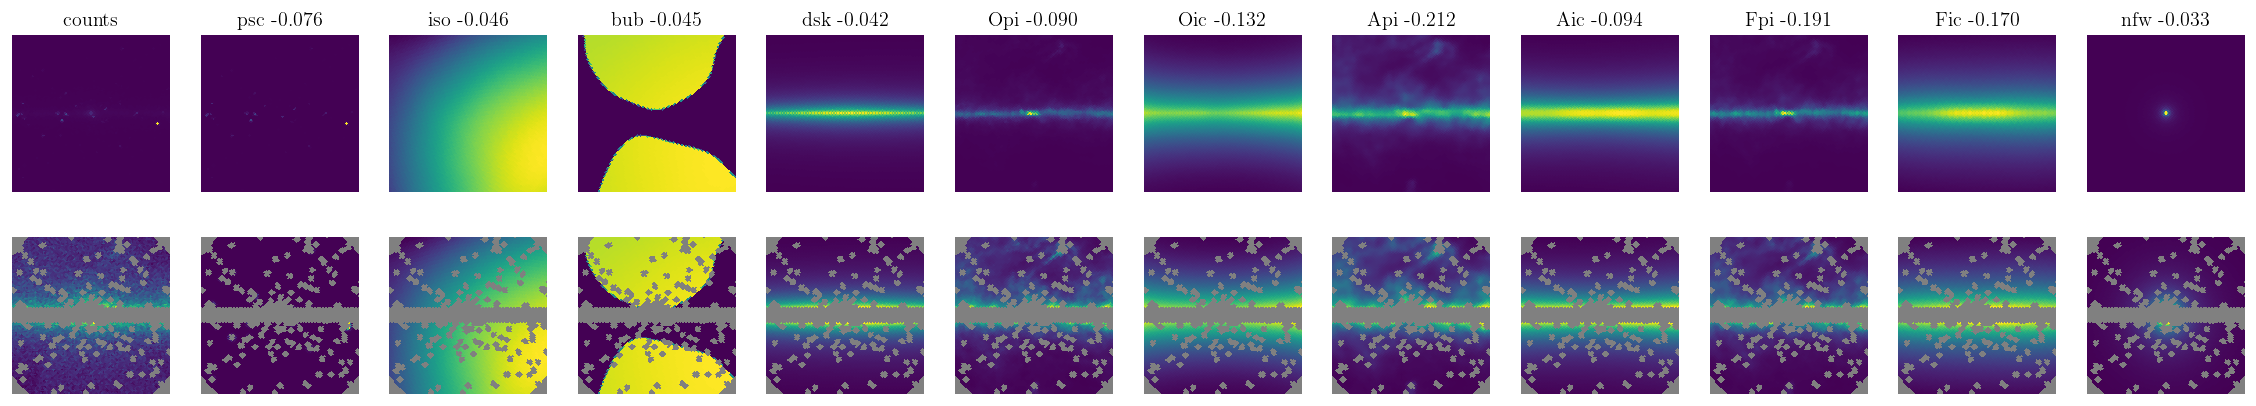

In [55]:
fig, axs = plt.subplots(2, 12, figsize=(24, 4))

hp_plot_kwargs = dict(lonra=[-20, 20], latra=[-20, 20], cbar=False, hold=True)

model = PoissonModel()
truth_arr = np.load(f"../../outputs/poiss_sim/svi_230823/truth_arr.npy")
model.set_truth(truth_arr)

rng_key = jax.random.PRNGKey(42)
counts = np.array(model.generate_counts(rng_key, unmasked=True), dtype=float)

plt.axes(axs[0, 0])
hp.visufunc.cartview(counts, title='counts', **hp_plot_kwargs)
plt.axes(axs[1, 0])
t = counts.copy()
t[model.mask_roi] = np.nan
hp.visufunc.cartview(t, title=None, **hp_plot_kwargs)

for i_temp in range(model.n_temp):
    plt.axes(axs[0, i_temp+1])
    hp.visufunc.cartview(model.temps_unmasked[i_temp], title=model.labels[i_temp] + f' {roc_scores[i_temp]:.3f}', **hp_plot_kwargs)

    t = model.temps_unmasked[i_temp].copy()
    t[model.mask_roi] = np.nan
    plt.axes(axs[1, i_temp+1])
    hp.visufunc.cartview(t, title=None, **hp_plot_kwargs)

plt.tight_layout()


## 3. Compare HMC and SVI posterior for one counts map

In [56]:
save_dir = "../../outputs/poiss_sim/svihmc_230826"

model = PoissonModel()
truth_arr = np.load(f"{save_dir}/truth_arr.npy")
model.set_truth(truth_arr)

# init
rng_key = jax.random.PRNGKey(42)
rng_key, key = jax.random.split(rng_key)
counts = model.generate_counts(rng_key)
np.save(f"{save_dir}/counts.npy", counts)

# run
rng_key, key = jax.random.split(rng_key)
model.fit_svi(key, guide='iaf', num_flows=5, hidden_dims=[128, 128],
              n_steps=2500, lr=5e-5, num_particles=8, counts=counts)
rng_key, key = jax.random.split(rng_key)
mcmc = model.run_nuts(
    num_chains=4, num_warmup=1000, num_samples=50000, step_size=0.01,
    rng_key=key, use_neutra=True, counts=counts
)
rng_key, key = jax.random.split(rng_key)
pickle.dump(mcmc.get_samples(), open(f"{save_dir}/samples_hmcnt.p", "wb"))
mcmc.print_summary()

sample: 100%|██████████| 51000/51000 [08:45<00:00, 96.96it/s] 



                            mean       std    median      5.0%     95.0%     n_eff     r_hat
 auto_shared_latent[0]     -0.68      2.18     -0.36     -3.69      2.59    643.55      1.01
 auto_shared_latent[1]      0.04      2.12      0.12     -3.44      3.50   1751.67      1.00
 auto_shared_latent[2]     -0.16      1.60     -0.21     -2.45      2.35   2982.24      1.00
 auto_shared_latent[3]     -0.48      3.07     -0.07     -5.43      4.27   1342.33      1.00
 auto_shared_latent[4]     -1.93      4.07     -0.97     -7.61      3.24   2522.83      1.00
 auto_shared_latent[5]     -0.96      5.51      0.57     -8.22      5.93    824.57      1.00
 auto_shared_latent[6]     -0.68      3.41     -0.80     -5.96      4.91   2292.67      1.00
 auto_shared_latent[7]     -3.93      6.43     -3.30    -13.37      6.26    976.68      1.00
 auto_shared_latent[8]     -0.85      2.97     -0.63     -5.03      3.93   1807.33      1.00
 auto_shared_latent[9]      1.19      3.97      1.67     -3.72      6

In [73]:
save_dir = "../../outputs/poiss_sim/svihmc_230826"

model = PoissonModel()
truth_arr = np.load(f"{save_dir}/truth_arr.npy")
model.set_truth(truth_arr)
counts = np.load(f"{save_dir}/counts.npy")

rng_key = jax.random.PRNGKey(42)
rng_key, key = jax.random.split(rng_key)
model.fit_svi(key, guide='iaf', num_flows=5, hidden_dims=[512, 512],
              n_steps=10000, lr=5e-5, num_particles=64, counts=counts)
rng_key, key = jax.random.split(rng_key)
samples = model.get_svi_samples(50000, key)
pickle.dump(samples, open(f"{save_dir}/samples_svi.p", "wb"))

100%|██████████| 10000/10000 [00:14<00:00, 698.09it/s, init loss: 64480.7109, avg. loss [9501-10000]: 20985.5469]


In [64]:
def rename_samples(samples, labels):
    new_samples = {}
    for i in range(len(labels)):
        new_samples[labels[i]] = samples[f'temp_{i}']
    return new_samples

In [74]:
samples_svi = pickle.load(open(f"{save_dir}/samples_svi.p", "rb"))
samples_hmc = pickle.load(open(f"{save_dir}/samples_hmcnt.p", "rb"))
samples_svi = rename_samples(samples_svi, model.labels)
samples_hmc = rename_samples(samples_hmc, model.labels)

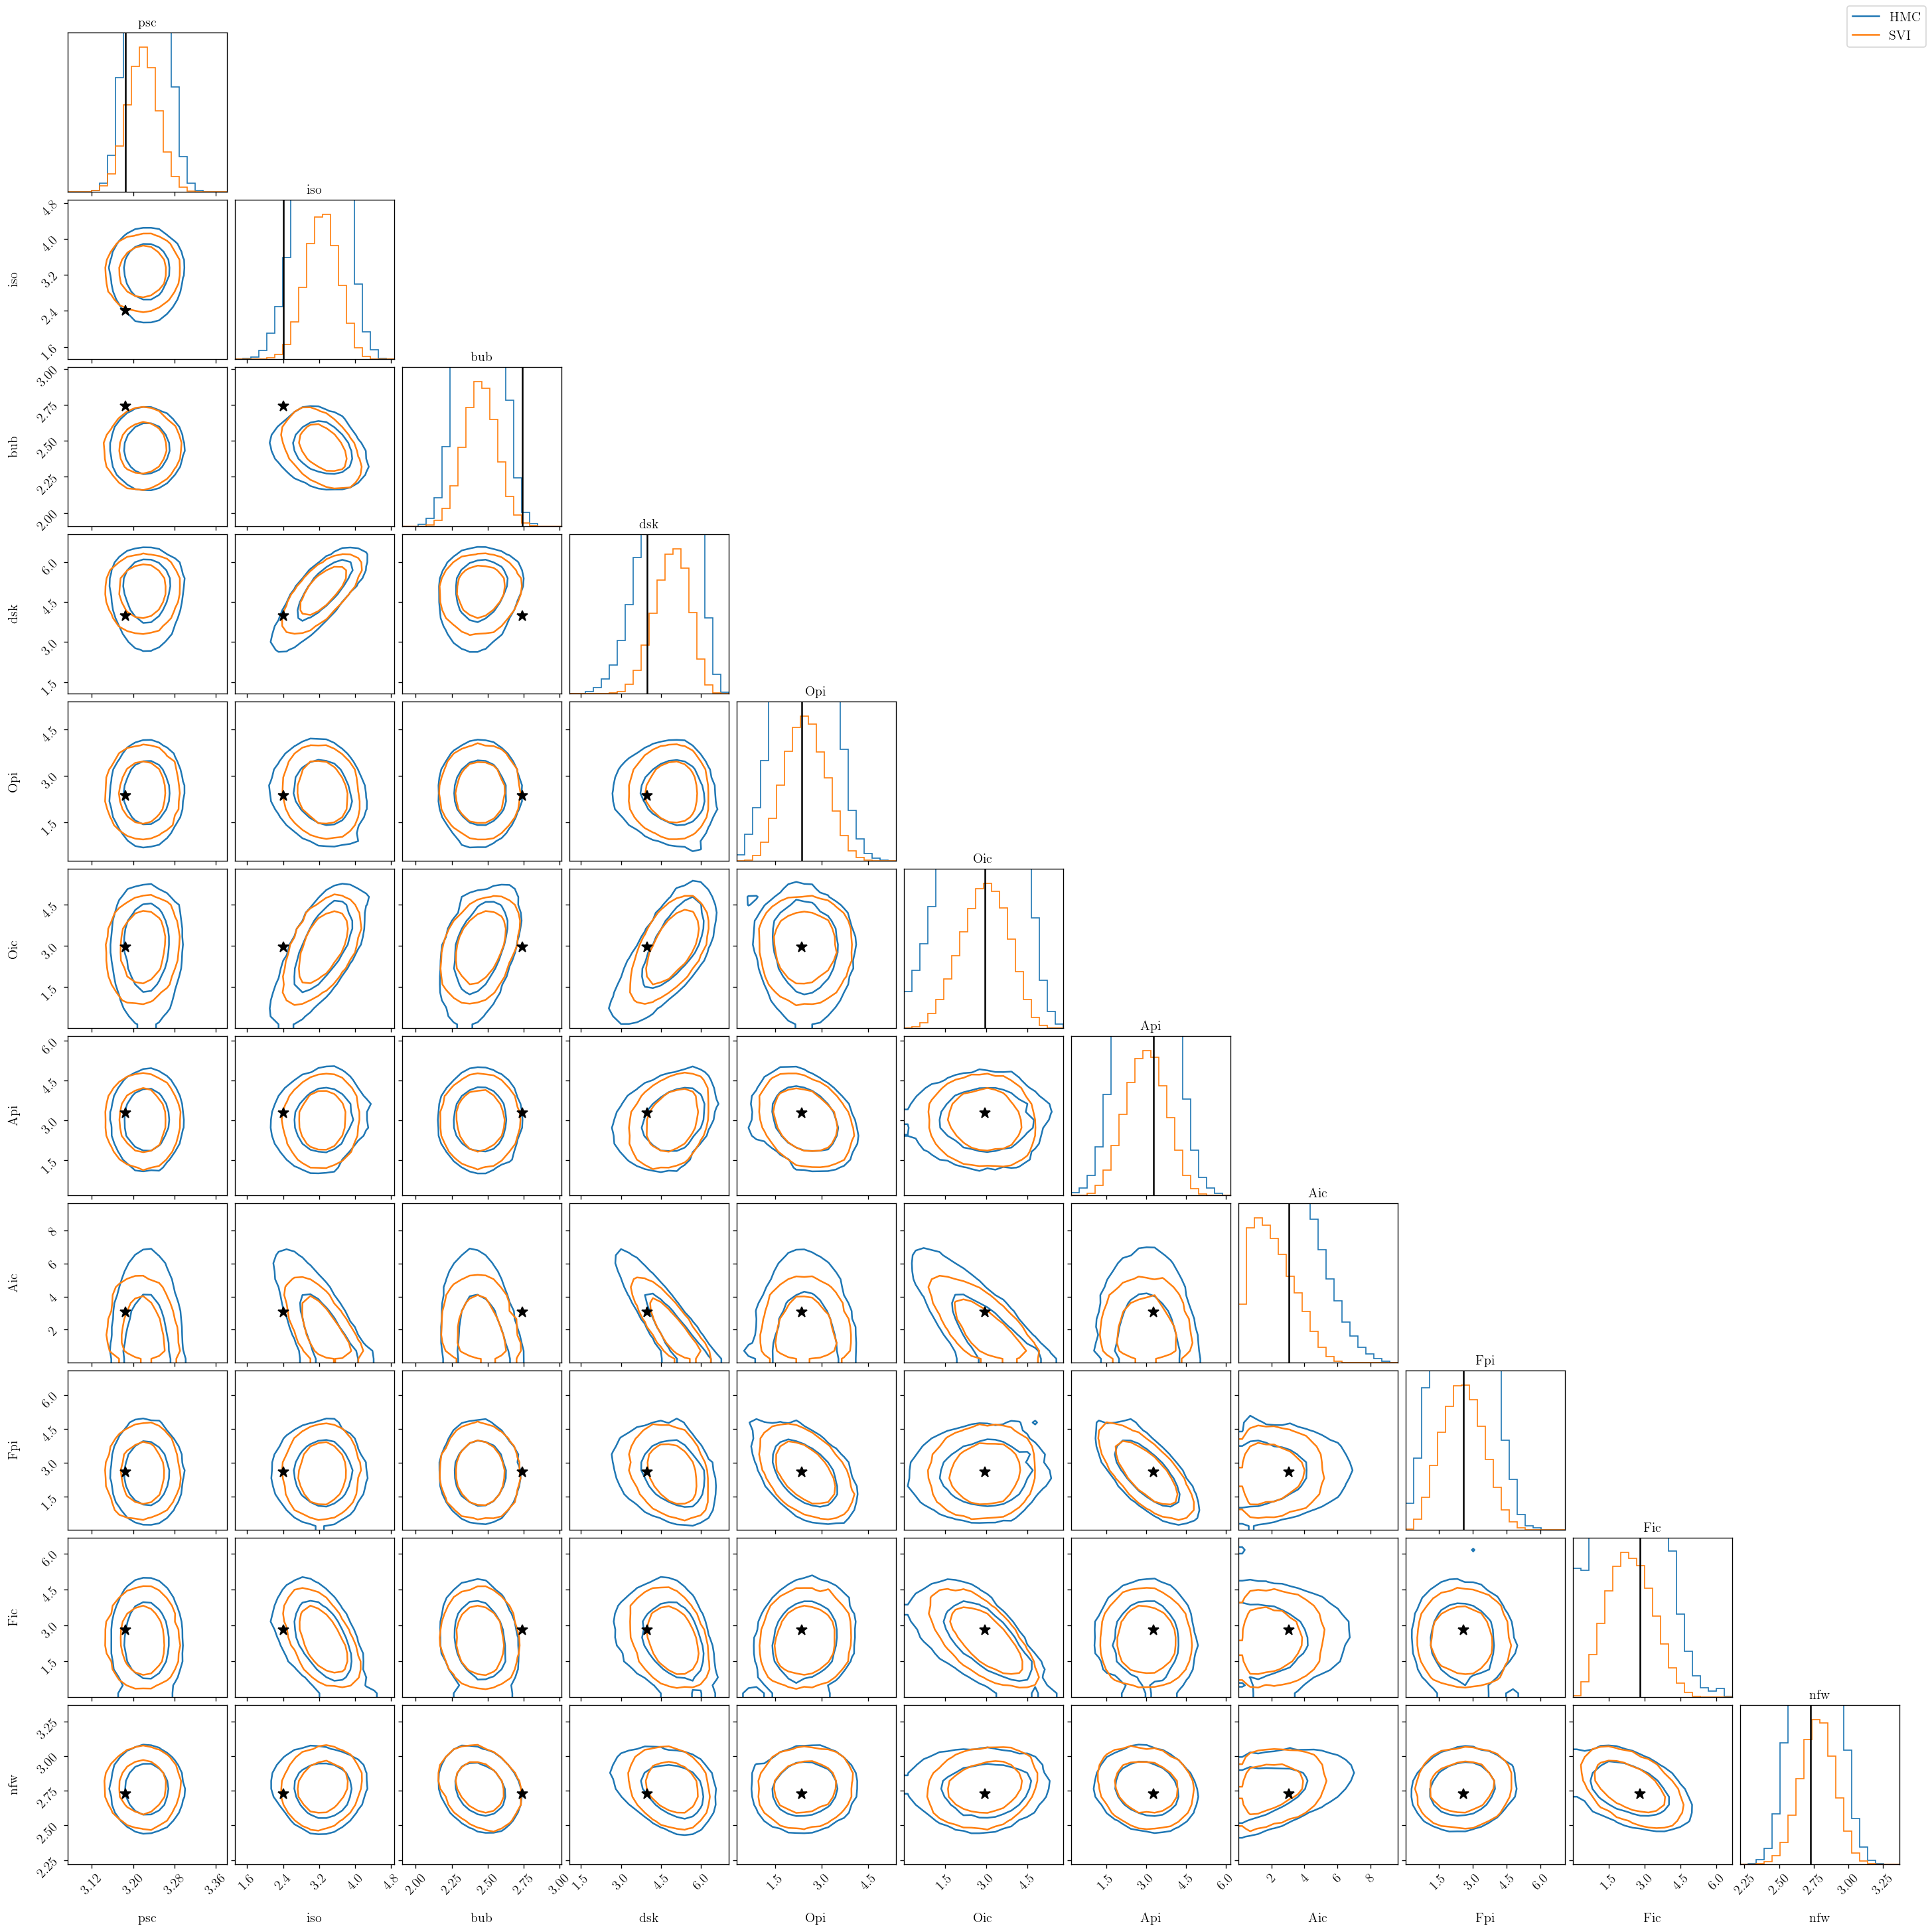

In [75]:
samples_dict = {'hmc' : samples_hmc, 'svi' : samples_svi}
colors_dict = {'hmc' : 'C0', 'svi' : 'C1'}
labels_dict = {'hmc' : 'HMC', 'svi' : 'SVI'}
plot_var_names = model.labels
truth_dict = {model.labels[i] : t for i, t in enumerate(truth_arr)}
multi_corner(
    samples_dict, plot_var_names, MAP=truth_dict,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1
)

## 4. How n_hidden n_steps num_particle affects overconfidence

| config | n_hidden | n_steps  | n_elbo_par | mean overconfidence | worst overconfidence |
|----------|----------|----------|----------|----------|----------|
| base | 512 | 10000 | 64 | 7.05% | 18.39% (Api) |
| | 512 | 10000 | 32 | 7.51% | 19.58% (Api) |
| | 512 | 10000 | 16 | 9.43% | 19.22% (Api) |
| | 512 |  5000 | 64 | 10.09% | 22.52% (Api) |
| | 512 |  2500 | 64 | 13.33% | 45.10% (Api) |
| | 256 | 10000 | 64 | 4.79% | 20.63% (Api) |
| | 128 | 10000 | 64 | 6.49% | 20.98% (Api) |
| more step | 512 | 20000 | 64 | 4.07% | 16.67% (psc) |

| less regularization | 512 | 10000 | 64 | % | % |

In [13]:
n_run = 30

invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
roc_standard = np.linspace(0, 1, n_run)
print(2 * 100 * np.sum(invcdf_upper - roc_standard) / n_run)
model = PoissonModel()
truth_arr = np.load(f"../../outputs/poiss_sim/truth_arr_230826.npy")
model.set_truth(truth_arr)

scan_list = [
    (512, 10000, 64),
    (512, 10000, 32), (512, 10000, 16),
    (512, 5000, 64),  (512, 2500, 64),
    (256, 10000, 64), (128, 10000, 64)
]

for nhidden, nsteps, npar in scan_list + [(512, 20000, 64)]:

    run_dir = f"../../outputs/poiss_sim/svi_230826_nhidden{nhidden}_nsteps{nsteps}_npar{npar}"
    if (nhidden, nsteps, npar) == (512, 10000, 64):
        run_dir = "../../outputs/poiss_sim/svi_230826"
    
    roc_runs = []
    for i_run in range(n_run):
        samples = pickle.load(open(f"{run_dir}/samples_{i_run}.p", "rb"))
        roc = []
        for i_temp in range(model.n_temp):
            s = np.array(samples[f'temp_{i_temp}'])
            m = truth_arr[i_temp]
            roc.append(find_hdi_prob(s, m, level=15))
        roc_runs.append(roc)
    roc_runs = np.array(roc_runs).T
    roc_runs = np.sort(roc_runs, axis=1)

    roc_scores = np.sum(- (roc_runs - roc_standard[None, :]) / n_run, axis=1)
    worst_index = np.argmin(roc_scores)
    print(f'| | {nhidden} | {nsteps:5d} | {npar} | {-2*np.mean(roc_scores)*100:.2f}% | {-2*np.min(roc_scores)*100:.2f}% ({model.labels[worst_index]}) |')

27.64784647743271
| | 512 | 10000 | 64 | 7.05% | 18.39% (Api) |
| | 512 | 10000 | 32 | 7.51% | 19.58% (Api) |
| | 512 | 10000 | 16 | 9.43% | 19.22% (Api) |
| | 512 |  5000 | 64 | 10.09% | 22.52% (Api) |
| | 512 |  2500 | 64 | 13.33% | 45.10% (Api) |
| | 256 | 10000 | 64 | 4.79% | 20.63% (Api) |
| | 128 | 10000 | 64 | 6.49% | 20.98% (Api) |
| | 512 | 20000 | 64 | 4.07% | 16.67% (psc) |


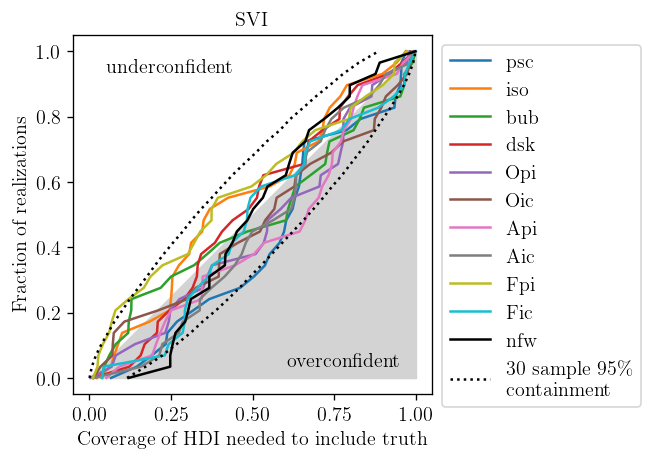

In [11]:
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for i, p in enumerate(roc_runs):
    color = f'C{i}'
    if model.labels[i] == 'nfw':
        color = 'k'
    ax.plot(p, np.linspace(0, 1, n_run), color=color, label=model.labels[i])

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
       title=f'SVI')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
#plt.savefig(f"{save_dir}/roc.pdf")

## A. Posterior

In [17]:
samples_plot = {k : s for k, s in samples.items() if k.startswith('temp_')}

In [19]:
model.labels

['psc', 'iso', 'bub', 'dsk', 'Opi', 'Oic', 'Api', 'Aic', 'Fpi', 'Fic', 'nfw']